## Notebook for autotune.py

## Run this for all imports and helper functions

### Imports

In [1]:
import numpy as np
from collections import OrderedDict
from IPython import display
import qiskit_metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

# Importing specific Qiskit Metal components for a planar superconducting quantum chip
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.toolbox_metal.parsing import parse_value

import sys 
import pandas as pd
# Importing Lumped Oscillator Model (LOM) analysis for extracting qubit parameters (fQ, alpha)

import logging

# Verify current Qiskit Metal version and environment
print(qiskit_metal.about())


Qiskit Metal        0.7.5

Basic
____________________________________
 Python              3.11.15 (main, May  4 2026, 21:17:00) [MSC v.1944 64 bit (AMD64)]
 Platform            Windows AMD64
 Installation path   C:\Users\DELL\chip-design\metal-flow\quantum-metal\src\qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.3.0

Rendering
____________________________________
 Matplotlib          3.11.0

GUI
____________________________________
 PySide6 version     6.11.1
 Qt version          6.11.1
 SIP version         Not installed

IBM Quantum Team

Qiskit Metal        0.7.5

Basic
____________________________________
 Python              3.11.15 (main, May  4 2026, 21:17:00) [MSC v.1944 64 bit (AMD64)]
 Platform            Windows AMD64
 Installation path   C:\Users\DELL\chip-design\metal-flow\quantum-metal\src\qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.3.0

Rend

### Helper class and functions

## Design

### Dict Init

In [11]:
from metal_flow.design import FOUR_QUBIT_DESIGN_DICT
from metal_flow.functions import create_design

Generating Launchpads...
Generating CoupledLineTee
Connecting...
Generating Qubits...
Generating Readout Resonators...
Generating Couplers...


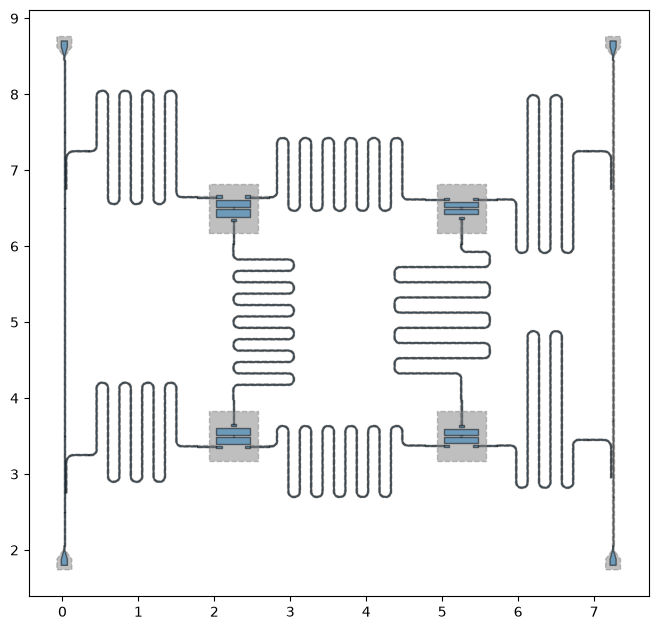

In [12]:
design = create_design(FOUR_QUBIT_DESIGN_DICT)
qiskit_metal.view(design)

## Execute Massive Sweep

In [ ]:
# ==============================================================================
# Execute Massive Sweep
# ==============================================================================
main_sweeps = {'pad_height': [i for i in range(60, 110, 10)]}

pad_width_min = 300
pad_width_max = 550
pad_width_step = 50

# pad_gap = 25

for pad_height in main_sweeps['pad_height']:

    for pad_gap in range(30, 55, 5):

        ## Boiler plate design
        design = create_design(FOUR_QUBIT_DESIGN_DICT)

        design.components.q0.options['pad_height'] = f"{pad_height} um"

        design.components.q0.options['pad_gap'] = f"{pad_gap} um"

        sweeps = {'pad_width':[f'{i} um' for i in range(pad_width_min, pad_width_max+pad_width_step, pad_width_step)]}

        # Main for loop for performing sweeps over all the variables. 
        for variable in sweeps.keys():

            print(f'{"pad_height"} = {pad_height}')
            print(f'pad_gap = {pad_gap} um')
            print(f"Performing Sweep : {variable} = {sweeps[variable]}")

            # Dictionary dictating the Ansys Q3D setup parameters for the sweep
            sweep_setup = Dict(design = design,
                            # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                            run_args_dict = Dict(components=[design.components.q0.name] , open_terminations=[(design.components.q0.name, pad) for pad in design.components.q0.pins.keys()]),
                            # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                            lom_setup = Dict(junctions=Dict(Lj=12, Cj=2), freq_readout=7.0,freq_bus=[6.0, 6.2]),
                            # Ansys Q3D Iterative solver properties
                            lom_sim_setup = Dict(name = 'sweep_Q3D', reuse_selected_design = True, reuse_setup = True, freq_ghz = 5.0, save_fields = True, enabled = True, max_passes = 15, min_passes = 2, min_converged_passes = 2, percent_error = 0.5, percent_refinement = 30, auto_increase_solution_order = True, solution_order = 'Highest', solver_type = 'Iterative'))

            # Instantiate the custom Sweeper class
            alpha_sweeper = Sweeper(sweep_setup=sweep_setup)

            # Trigger the sweep on q0's pad_gap, analyzing 4 distinct values and tracking Qubit Frequency (fQ) and Anharmonicity (alpha)
            alpha_sweeper.perform_sweep(name = f'{variable}_{pad_width_min}_{pad_width_max}_pad_height_{pad_height}_pad_gap_{pad_gap}', sweep_component_options = design.components.q0.options,
                                        sweep_variable = variable,
                                        sweep_values = sweeps[variable])


## Tune all 4 Qubits

In [ ]:
design = create_design(FOUR_QUBIT_DESIGN_DICT)

In [ ]:

data_list = []


for qubit in FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz.keys():
    


    sweep_setup = Dict(design = design,
                        # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                        run_args_dict = Dict(components=[design.components[qubit].name] , open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()]),
                        # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                        lom_setup = Dict(junctions=Dict(Lj=12, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit]),
                        # Ansys Q3D Iterative solver properties
                        lom_sim_setup = Dict(name = f'{qubit}_setup', reuse_selected_design = True, reuse_setup = True, freq_ghz = FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz[qubit], save_fields = True, enabled = True, max_passes = 30, min_passes = 2, min_converged_passes = 3, percent_error = 0.05, percent_refinement = 30, auto_increase_solution_order = True, solution_order = 'Highest', solver_type = 'Iterative'))

    cap_lom = LOManalysis(sweep_setup.design, 'q3d')

    cap_lom.clear_data()

    cap_lom.sim.design.rebuild()

    cap_lom.setup = sweep_setup.lom_setup
    cap_lom.sim.setup = sweep_setup.lom_sim_setup

    cap_lom.sim.run(components = sweep_setup.run_args_dict.components, open_terminations = sweep_setup.run_args_dict.open_terminations, box_plus_buffer=True)

    cap_lom.run_lom()

    cap_lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
    cap_lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")
    
    data_dict = {'Qubit':qubit, 'pad_gap':design.components[qubit].options.pad_gap, 'pad_width':design.components[qubit].options.pad_width, 'pad_height':design.components[qubit].options.pad_height, 'cap_matrix':cap_lom.sim.capacitance_matrix}


    data_dict.update(cap_lom.lumped_oscillator)

    

    data_list.append(data_dict)



data_df = pd.DataFrame(data_list)

data_df.to_csv("all_tuned_qubits.csv", index=False)



In [ ]:
# q0 - r0 = 1.8
# c01 - q0 = 1.0
# c01 - q1 = 1.2
# c01 - r0 = 0.8
# c01 - r1 = 1.2
# q1 - r1  = 2.4

# q0 <    q1          <    c01         <    r0         <    r1

# q0 , q0 + [0.3, 0.5], q0 + [1.0, 1.2], q0 + [1.2,1.5], q0 + [1.5, 1.8]


In [ ]:
design = create_design(FOUR_QUBIT_DESIGN_DICT)
# gui = MetalGUI(design)
# gui.autoscale()
# gui.show()

## Tuning Q0

### Q3D

In [5]:
from qiskit_metal.analyses import LOManalysis
qubit = 'q0'

lom = LOManalysis(design, 'q3d')

sweep_setup = Dict(design = design,
                        # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                        run_args_dict = Dict(components=[design.components[qubit].name] , open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()]),
                        # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                        lom_setup = Dict(junctions=Dict(Lj=12.4, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit]),
                        # Ansys Q3D Iterative solver properties
                        lom_sim_setup = Dict(name = f'{qubit}_setup', reuse_selected_design = True, reuse_setup = True, freq_ghz = FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz[qubit], save_fields = True, enabled = True, max_passes = 30, min_passes = 2, min_converged_passes = 3, percent_error = 0.05, percent_refinement = 30, auto_increase_solution_order = True, solution_order = 'Highest', solver_type = 'Iterative'))



lom.sim.design.rebuild()

lom.setup = sweep_setup.lom_setup
lom.sim.setup = sweep_setup.lom_sim_setup

lom.sim.run(components = sweep_setup.run_args_dict.components, open_terminations = sweep_setup.run_args_dict.open_terminations, box_plus_buffer=True)

# lom.run_lom()

# lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
# lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")


INFO 03:59PM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:59PM [load_ansys_project]: 	Opened Ansys App
INFO 03:59PM [load_ansys_project]: 	Opened Ansys Desktop v2025.1.4
INFO 03:59PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/DELL/Documents/Ansoft/
	Project:   Project305
INFO 03:59PM [connect_design]: No active design found (or error getting active design).
INFO 03:59PM [connect]: 	 Connected to project "Project305". No design detected
INFO 03:59PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
WARNING 03:59PM [connect_setup]: 	No design setup detected.
WARNING 03:59PM [connect_setup]: 	Creating Q3D default setup.
INFO 03:59PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:59PM [get_setup]: 	Opened setup `q0_setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 03:59PM [analyze]: Analyzing setup q0_setup
INFO 04:20PM [get_matrix]: Exporting matrix data to (C:\Users\DELL\AppData\L

In [9]:
lom.setup = Dict(junctions=Dict(Lj=12.4, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz['q0'], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq['q0'])
lom.run_lom()

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 5.009258 [GHz]
EC 265.485754 [MHz]
EJ 13.171751 [GHz]
alpha -305.130293 [MHz]
dispersion 11.166664 [KHz]
Lq 12.400000 [nH]
Cq 72.961460 [fF]
T1 1120.673025 [us]

**Coupling Properties**

tCqbus1 -3.108542 [fF]
gbus1_in_MHz -6.083706 [MHz]
χ_bus1 -0.002180 [MHz]
1/T1bus1 0.639991 [Hz]
T1bus1 248683.260948 [us]

tCqbus2 4.112206 [fF]
gbus2_in_MHz 48.163430 [MHz]
χ_bus2 -1.114636 [MHz]
1/T1bus2 117.423604 [Hz]
T1bus2 1355.391402 [us]

tCqbus3 -3.108601 [fF]
gbus3_in_MHz -41.876978 [MHz]
χ_bus3 -0.265511 [MHz]
1/T1bus3 23.953693 [Hz]
T1bus3 6644.275802 [us]
Bus-Bus Couplings
gbus1_2 0.354511 [MHz]
gbus1_3 0.341428 [MHz]
gbus2_3 2.422625 [MHz]


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,5.4777,321.321863,13.171751,-376.116807,64.048056,"[-5.562201108919958, 51.13419347345309, -47.68...","[-0.001856004083338281, -4.20701375538078, -0....",0.001856,5.562201
2,5.412137,313.137824,13.171751,-365.567009,51.094999,"[-6.094202813339124, 49.567089854947, -42.1507...","[-0.002221235656406007, -3.2191794558747056, -...",0.002221,6.094203
3,5.278255,296.802314,13.171751,-344.659628,31.643502,"[-5.832232780478231, 47.71503346138777, -41.16...","[-0.0020226741484400176, -2.051765776132006, -...",0.002023,5.832233
4,5.179371,285.058341,13.171751,-329.751331,21.855045,"[-5.848451993810498, 48.19237836372962, -40.27...","[-0.002026130178300699, -1.6351289737671217, -...",0.002026,5.848452
5,5.131518,279.472288,13.171751,-322.695832,18.176266,"[-5.971263794468596, 47.6614527910688, -41.013...","[-0.002108464106235126, -1.429350379077297, -0...",0.002108,5.971264
6,5.099265,275.742814,13.171751,-317.998043,16.021021,"[-5.969931038815085, 47.46551605196438, -41.01...","[-0.002105169321836011, -1.3172588691815665, -...",0.002105,5.969931
7,5.07245,272.66384,13.171751,-314.127321,14.407126,"[-6.015530918350226, 47.51781610886793, -41.31...","[-0.0021355325692911744, -1.2436011830255007, ...",0.002136,6.015531
8,5.055729,270.75393,13.171751,-311.729766,13.476348,"[-5.998147680329676, 47.739380515221534, -41.2...","[-0.0021220495641633866, -1.210013556226001, -...",0.002122,5.998148
9,5.046614,269.715909,13.171751,-310.42783,12.992028,"[-6.008096138105438, 47.65751459784897, -41.36...","[-0.0021284710492682074, -1.1822006931850595, ...",0.002128,6.008096
10,5.035647,268.470146,13.171751,-308.866373,12.430168,"[-6.029799050359556, 47.70714753691025, -41.49...","[-0.0021431301255090207, -1.1569374877581662, ...",0.002143,6.029799


In [ ]:
lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")

In [13]:
lom.sim.close()


### Eigenmode


In [ ]:
from qiskit_metal.analyses.quantization import EPRanalysis
import pyEPR as epr

eig_qb_0 = EPRanalysis(design, "hfss")

In [ ]:
eig_qb_0.sim.setup

In [ ]:
design.components.q0.options.hfss_inductance = '12.5 nH'
design.components.q0.options.hfss_capacitence = '0 fF'

In [ ]:
# example: update single setting
design.rebuild()
eig_qb_0.clear_data()
eig_qb_0.sim.setup.max_passes = 30
eig_qb_0.sim.setup.vars.mesh_kw_jj = '7um'
# example: update multiple settings
eig_qb_0.sim.setup_update(max_delta_f = 0.1, min_freq_ghz = 1.1, n_modes=1, pct_refinement=30)

eig_qb_0.sim.setup

In [ ]:
qubit = 'q0'
# my_port_list = [(design.components[qubit].name, pad,  50) for pad in design.components[qubit].pins.keys()]
eig_qb_0.sim.run(name=f'{qubit}_eig', components=[design.components[qubit].name], open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()], port_list=[])

In [ ]:
eig_qb_0.sim.plot_convergences()

In [ ]:
# eig_qb.setup.run    <- direct access
eig_qb_0.sim.print_run_args()

In [ ]:
eig_qb_0.sim.convergence_f

In [ ]:
eig_qb_0.sim.plot_fields('main')   # TODO:::: Ez, normal component.....decide which field typically on the qbit, or on the crossing between meanders

In [ ]:
eig_qb_0.sim.clear_fields()

## Tune Q1

### Q3D

In [ ]:
qubit = 'q1'
lom = LOManalysis(design, 'q3d')

sweep_setup = Dict(design = design,
                        # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                        run_args_dict = Dict(components=[design.components[qubit].name] , open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()]),
                        # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                        lom_setup = Dict(junctions=Dict(Lj=14, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit]),
                        # Ansys Q3D Iterative solver properties
                        lom_sim_setup = Dict(name = f'{qubit}_setup', reuse_selected_design = True, reuse_setup = True, freq_ghz = FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz[qubit], save_fields = True, enabled = True, max_passes = 30, min_passes = 2, min_converged_passes = 3, percent_error = 0.05, percent_refinement = 30, auto_increase_solution_order = True, solution_order = 'Highest', solver_type = 'Iterative'))



lom.sim.design.rebuild()

lom.setup = sweep_setup.lom_setup
lom.sim.setup = sweep_setup.lom_sim_setup

lom.sim.run(components = sweep_setup.run_args_dict.components, open_terminations = sweep_setup.run_args_dict.open_terminations, box_plus_buffer=True)

# lom.run_lom()

# lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
# lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")


In [ ]:
lom.setup = Dict(junctions=Dict(Lj=11.5, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit])
lom.run_lom()

In [ ]:
lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")

In [ ]:
lom.sim.close()


### Eigenmode


In [ ]:
from qiskit_metal.analyses.quantization import EPRanalysis
import pyEPR as epr

eig_qb_1 = EPRanalysis(design, "hfss")
qubit = 'q1'

In [ ]:
eig_qb_1.sim.setup

In [ ]:
design.components[qubit].options.hfss_inductance = '13.0 nH'
design.components[qubit].options.hfss_capacitence = '0 fF'

In [ ]:
# example: update single setting
design.rebuild()
eig_qb_1.clear_data()
eig_qb_1.sim.setup.max_passes = 30
eig_qb_1.sim.setup.vars.mesh_kw_jj = '7um'
# example: update multiple settings
eig_qb_1.sim.setup_update(max_delta_f = 0.1, min_freq_ghz = 1.1, n_modes=1, pct_refinement=30, )
eig_qb_1.sim.setup.vars.Lj = '10.0 nH'
eig_qb_1.sim.setup

In [ ]:

# my_port_list = [(design.components[qubit].name, pad,  50) for pad in design.components[qubit].pins.keys()]
eig_qb_1.sim.run(name=f'{qubit}_eig', components=[design.components[qubit].name], open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()], box_plus_buffer = False, port_list=[])

In [ ]:
eig_qb_1.sim.plot_convergences()

In [ ]:
# eig_qb.setup.run    <- direct access
eig_qb_1.sim.print_run_args()

In [ ]:
eig_qb_1.sim.convergence_f

In [ ]:
eig_qb_1.sim.plot_fields('main')   # TODO:::: Ez, normal component.....decide which field typically on the qbit, or on the crossing between meanders

In [ ]:
eig_qb_1.sim.clear_fields()

In [ ]:
eig_qb_1.sim.close()

## Tuning Q2

In [ ]:
for qubit in ['q0', 'q1', 'q2', 'q3']:
    print(design.components[qubit].options.pad_height)

In [ ]:
qubit = 'q2'
design.components[qubit].options.pad_width = '400 um'
design.components[qubit].options.pad_height = '80 um'
print(design.components[qubit].options.pad_height)
print(design.components[qubit].options.pad_gap)
design.rebuild()

### Q3D

In [ ]:

lom = LOManalysis(design, 'q3d')

sweep_setup = Dict(design = design,
                        # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                        run_args_dict = Dict(components=[design.components[qubit].name] , open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()]),
                        # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                        lom_setup = Dict(junctions=Dict(Lj=11, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit]),
                        # Ansys Q3D Iterative solver properties
                        lom_sim_setup = Dict(name = f'{qubit}_setup', reuse_selected_design = True, reuse_setup = True, freq_ghz = FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz[qubit], save_fields = True, enabled = True, max_passes = 30, min_passes = 2, min_converged_passes = 3, percent_error = 0.05, percent_refinement = 30, auto_increase_solution_order = True, solution_order = 'Highest', solver_type = 'Iterative'))



lom.sim.design.rebuild()

lom.setup = sweep_setup.lom_setup
lom.sim.setup = sweep_setup.lom_sim_setup

lom.sim.run(components = sweep_setup.run_args_dict.components, open_terminations = sweep_setup.run_args_dict.open_terminations, box_plus_buffer=True)

# lom.run_lom()

# lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
# lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")


In [ ]:
lom.setup = Dict(junctions=Dict(Lj=10, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit])
lom.run_lom()

In [ ]:
lom.plot_convergence()
lom.plot_convergence_chi()

In [ ]:
lom.sim.close()


### Eigenmode


In [ ]:
from qiskit_metal.analyses.quantization import EPRanalysis
import pyEPR as epr

eig_qb_2 = EPRanalysis(design, "hfss")
qubit='q2'

In [ ]:
eig_qb_2.sim.setup

In [ ]:
design.components[qubit].options.hfss_inductance = '11.2 nH'
design.components[qubit].options.hfss_capacitence = '0 fF'

In [ ]:
# example: update single setting
design.rebuild()
eig_qb_2.clear_data()
eig_qb_2.sim.setup.max_passes = 30
eig_qb_2.sim.setup.vars.mesh_kw_jj = '7um'
# example: update multiple settings
eig_qb_2.sim.setup_update(max_delta_f = 0.1, min_freq_ghz = 1.1, n_modes=1, pct_refinement=30)

eig_qb_2.sim.setup

In [ ]:

# my_port_list = [(design.components[qubit].name, pad,  50) for pad in design.components[qubit].pins.keys()]
eig_qb_2.sim.run(name=f'{qubit}_eig', components=[design.components[qubit].name], open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()], box_plus_buffer = False, port_list=[])

In [ ]:
eig_qb_2.sim.plot_convergences()

In [ ]:
# eig_qb.setup.run    <- direct access
eig_qb_2.sim.print_run_args()

In [ ]:
eig_qb_2.sim.convergence_f

In [ ]:
eig_qb_2.sim.plot_fields('main')   # TODO:::: Ez, normal component.....decide which field typically on the qbit, or on the crossing between meanders

In [ ]:
eig_qb_2.sim.clear_fields()

## Tune Q3


### Q3D

In [ ]:
qubit = 'q3'
lom = LOManalysis(design, 'q3d')

sweep_setup = Dict(design = design,
                        # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                        run_args_dict = Dict(components=[design.components[qubit].name] , open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()]),
                        # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                        lom_setup = Dict(junctions=Dict(Lj=11, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit]),
                        # Ansys Q3D Iterative solver properties
                        lom_sim_setup = Dict(name = f'{qubit}_setup', reuse_selected_design = True, reuse_setup = True, freq_ghz = FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz[qubit], save_fields = True, enabled = True, max_passes = 30, min_passes = 2, min_converged_passes = 3, percent_error = 0.05, percent_refinement = 30, auto_increase_solution_order = True, solution_order = 'Highest', solver_type = 'Iterative'))



lom.sim.design.rebuild()

lom.setup = sweep_setup.lom_setup
lom.sim.setup = sweep_setup.lom_sim_setup

lom.sim.run(components = sweep_setup.run_args_dict.components, open_terminations = sweep_setup.run_args_dict.open_terminations, box_plus_buffer=True)

# lom.run_lom()

# lom.plot_convergence().savefig(f"{qubit}_tuned_main.png")
# lom.plot_convergence_chi().savefig(f"{qubit}_chi_tuned_main.png")


In [ ]:
lom.setup = Dict(junctions=Dict(Lj=11, Cj=2), freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_hz[qubit], freq_bus=FOUR_QUBIT_DESIGN_DICT.bus_freq[qubit])
lom.run_lom()

In [ ]:
lom.plot_convergence()
lom.plot_convergence_chi()

In [ ]:
lom.sim.close()


### Eigenmode

In [ ]:
from qiskit_metal.analyses.quantization import EPRanalysis
import pyEPR as epr

eig_qb_3 = EPRanalysis(design, "hfss")
qubit='q3'

In [ ]:
eig_qb_3.sim.setup

In [ ]:
design.components[qubit].options.hfss_inductance = '12.4 nH'
design.components[qubit].options.hfss_capacitence = '0 fF'

In [ ]:
# example: update single setting
design.rebuild()
eig_qb_3.clear_data()
eig_qb_3.sim.setup.max_passes = 30
eig_qb_3.sim.setup.vars.mesh_kw_jj = '7um'
# example: update multiple settings
eig_qb_3.sim.setup_update(max_delta_f = 0.1, min_freq_ghz = 1.1, n_modes=1, pct_refinement=30)

eig_qb_3.sim.setup

In [ ]:

# my_port_list = [(design.components[qubit].name, pad,  50) for pad in design.components[qubit].pins.keys()]
eig_qb_3.sim.run(name=f'{qubit}_eig', components=[design.components[qubit].name], open_terminations=[(design.components[qubit].name, pad) for pad in design.components[qubit].pins.keys()], port_list=[])

In [ ]:
eig_qb_3.sim.plot_convergences()

In [ ]:
# eig_qb.setup.run    <- direct access
eig_qb_3.sim.print_run_args()

In [ ]:
eig_qb_3.sim.convergence_f

In [ ]:
eig_qb_3.sim.plot_fields('main')   # TODO:::: Ez, normal component.....decide which field typically on the qbit, or on the crossing between meanders

In [ ]:
eig_qb_3.sim.clear_fields()

In [ ]:
eig_qb_3.sim.close()

## Feedlines Only

### feedline_02

### S-Params Analysis (Broad)

In [ ]:
design = create_design(FOUR_QUBIT_DESIGN_DICT)

In [ ]:
from qiskit_metal.analyses import ScatteringImpedanceSim

def simulate_s_params(design, design_name, selection, open_pins, port_list, box_plus_buffer):
    ##################################################################################
    ##################################################################################
    ### DO NOT DELETE THIS. IT WORKS FOR WIN(ANSYS) -> LINUX(ANSYS) THORUGH _analyze()
    ##################################################################################
    ##################################################################################
    em = ScatteringImpedanceSim(design, "hfss")

    em.renderer.activate_ansys_design(design_name, 'drivenmodal')
    
    em.setup_update(freq_ghz=6,
                    max_delta_s=0.001,
                    basis_order=-1,
                    min_passes=1,
                    max_passes=35,
                    min_converged=2,
                    pct_refinement=30,
                    vars=Dict(Lj='10 nH', Cj='0 fF'),

                    sweep_setup={'name': 'Sweep',
                'start_ghz': 2.0,
                'stop_ghz': 10.0,
                'count': 10001,
                'type': 'Interpolating',
                'save_fields': True, 
                })

    print(em.setup)
    # em.renderer.start()

    em.setup.renderer.options['x_buffer_width_mm'] = 0.1
    em.setup.renderer.options['y_buffer_width_mm'] = 0.1
    
    # em.renderer.modeler.mesh_length("cpw_mesh", ["trace_meander"], MaxLength="0.05mm")

    em._render(name = design_name,
                selection=selection,
                solution_type="drivenmodal",
                vars_to_initialize=em.setup.vars,
                open_pins=open_pins,
                port_list=port_list,
                box_plus_buffer=box_plus_buffer)
    # return em
    em._analyze()

    result_dict = Dict(S=Dict(Params=None, fig=None), Y=Dict(Params=None, fig=None), Z=Dict(Params=None, fig=None), convergence=Dict(conv_t=None, conv_f=None, text=None))

    result_dict.S.Params, result_dict.S.fig = em.renderer.plot_params([f'S{i}1' for i in range(1, len(port_list)+1)] )

    result_dict.Z.Params, result_dict.Z.fig = em.renderer.plot_params([f'Z{i}1' for i in range(1, len(port_list)+1)] )

    result_dict.Y.Params, result_dict.Y.fig = em.renderer.plot_params([f'Y{i}1' for i in range(1, len(port_list)+1)] )

    result_dict.convergence.conv_t, result_dict.convergence.conv_f, result_dict.convergence.text = em.renderer.get_convergences()

    em.close()
    
    print(result_dict.convergence.text)
    return result_dict

    ##################################################################################
    ##################################################################################
    ### DO NOT DELETE THIS. IT WORKS FOR WIN(ANSYS) -> LINUX(ANSYS) THORUGH _analyze()
    ##################################################################################
    ##################################################################################


    
    
    

In [ ]:
feedline02_result = simulate_s_params(design=design, design_name="feedline_02", 
                                                  selection=['p0', 'p2', 'feedline_02'], 
                                                  open_pins=[], 
                                                  port_list=[('p0', 'in', 50), ('p2', 'in', 50)], 
                                                  box_plus_buffer=True)



### S-Params Analysis (Narrowed near 4GHz and 8GHz)

In [ ]:
from qiskit_metal.analyses import ScatteringImpedanceSim

def simulate_s_params_1(design, design_name, selection, open_pins, port_list, box_plus_buffer):
    ##################################################################################
    ##################################################################################
    ### DO NOT DELETE THIS. IT WORKS FOR WIN(ANSYS) -> LINUX(ANSYS) THORUGH _analyze()
    ##################################################################################
    ##################################################################################
    em = ScatteringImpedanceSim(design, "hfss")

    em.renderer.activate_ansys_design(design_name, 'drivenmodal')
    
    em.setup_update(freq_ghz=4,
                    max_delta_s=0.001,
                    basis_order=-1,
                    min_passes=1,
                    max_passes=35,
                    min_converged=2,
                    pct_refinement=30,
                    vars=Dict(Lj='10 nH', Cj='0 fF'),

                    sweep_setup={'name': 'Sweep',
                'start_ghz': 3.0,
                'stop_ghz': 5.0,
                'count': 1001,
                'type': 'Interpolating',
                'save_fields': True, 
                })

    print(em.setup)
    # em.renderer.start()

    em.setup.renderer.options['x_buffer_width_mm'] = 0.1
    em.setup.renderer.options['y_buffer_width_mm'] = 0.1
    
    # em.renderer.modeler.mesh_length("cpw_mesh", ["trace_meander"], MaxLength="0.05mm")

    em._render(name = design_name,
                selection=selection,
                solution_type="drivenmodal",
                vars_to_initialize=em.setup.vars,
                open_pins=open_pins,
                port_list=port_list,
                box_plus_buffer=box_plus_buffer)
    # return em
    em._analyze()

    result_dict = Dict(S=Dict(Params=None, fig=None), Y=Dict(Params=None, fig=None), Z=Dict(Params=None, fig=None), convergence=Dict(conv_t=None, conv_f=None, text=None))

    result_dict.S.Params, result_dict.S.fig = em.renderer.plot_params([f'S{i}1' for i in range(1, len(port_list)+1)] )

    result_dict.Z.Params, result_dict.Z.fig = em.renderer.plot_params([f'Z{i}1' for i in range(1, len(port_list)+1)] )

    result_dict.Y.Params, result_dict.Y.fig = em.renderer.plot_params([f'Y{i}1' for i in range(1, len(port_list)+1)] )

    result_dict.convergence.conv_t, result_dict.convergence.conv_f, result_dict.convergence.text = em.renderer.get_convergences()

    em.renderer.close()
    
    print(result_dict.convergence.text)
    return result_dict

    ##################################################################################
    ##################################################################################
    ### DO NOT DELETE THIS. IT WORKS FOR WIN(ANSYS) -> LINUX(ANSYS) THORUGH _analyze()
    ##################################################################################
    ##################################################################################



    
    

In [ ]:
feedline02_result_4ghz = simulate_s_params_1(design=design, design_name="feedline_02_1", 
                                            selection=['p0', 'p2', 'feedline_02'], 
                                            open_pins=[], 
                                            port_list=[('p0', 'in', 50), ('p2', 'in', 50)], 
                                            box_plus_buffer=True)
 

In [ ]:
import matplotlib.pyplot as plt
def plot_multiple_complex_arrays(*complex_arrays, labels=None):
    """
    Plots multiple arrays of complex numbers on a single 2D plane.
    
    Parameters:
    *complex_arrays : Arbitrary number of lists containing complex numbers.
    labels (list)   : Optional list of strings to label each array in the legend.
    """
    plt.figure(figsize=(9, 9))
    
    # Iterate through each array passed to the function
    for i, complex_numbers in enumerate(complex_arrays):
        real_parts = [z.real for z in complex_numbers]
        imag_parts = [z.imag for z in complex_numbers]
        
        # Determine the label for the legend
        if labels and i < len(labels):
            current_label = labels[i]
        else:
            current_label = f'Array {i + 1}'
            
        # Plot this specific array (Matplotlib automatically assigns a new color)
        plt.scatter(real_parts, imag_parts, marker='o', label=current_label, zorder=3, s=1)

        

    # Configure axes and grid
    plt.axhline(0, color='black', linewidth=1.5, zorder=1) # X-axis
    plt.axvline(0, color='black', linewidth=1.5, zorder=1) # Y-axis
    plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

    # Set labels, title, and legend
    plt.xlabel('Real Axis')
    plt.ylabel('Imaginary Axis')
    plt.title('Complex Plane (Multiple Arrays)')
    plt.legend()

    # Ensure the aspect ratio is 1:1
    plt.axis('equal')

    # Display the plot
    plt.show()

plot_multiple_complex_arrays(feedline02_result.S.Params['S11'], feedline02_result.S.Params['S21'], labels=['S11', 'S21'])

### feedline13

In [ ]:
feedline13_result = simulate_s_params(design=design, design_name="feedline_13", 
                                                  selection=['p1', 'p3', 'feedline_13'], 
                                                  open_pins=[], 
                                                  port_list=[('p1', 'in', 50), ('p3', 'in', 50)], 
                                                  box_plus_buffer=True)



## EPR Analysis

In [ ]:
eig_qb.setup

In [ ]:
eig_qb.setup.junctions.jj.rect = 'JJ_rect_Lj_q0_rect_jj'
eig_qb.setup.junctions.jj.line = 'JJ_Lj_q0_rect_jj_'
eig_qb.setup

In [ ]:
eig_qb.run_epr()

#### equivalent individual calls
# s = eig_qb.setup
# eig_qb.epr_start()
# eig_qb.get_stored_energy()


In [ ]:
# eig_qb.run_analysis()


In [ ]:
eig_qb.sim.close()